# Image Lag 模型拟合

升级 Hammerstein 模型：释放核 **h(t; F)** 随信号强度 F = f\_trap(Q) 变化

| 章节 | 内容 |
|------|------|
| 1 | 陷阱填充：`f_trap(Q) = Nt·(1−exp(−Q/Qc))` |
| 2 | Q 依赖释放核：`h(t;F) = A1(F)·g_fast + (1−A1(F))·g_slow` |
| 3 | 集成参数与验证 |

## 1. 陷阱填充模型（Mitscherlich）

`f_trap(Q) = Nt · (1 − exp(−Q / Qc))`

训练集：8 组 Q-peak 数据；验证集：9 组独立数据

拟合结果 (基于8个训练点): f(Q) = Nt * (1 - exp(-Q/Qc))
  Nt  = 62.63 ± 1.00 DN
  Qc  = 85.4 ± 4.1 DN
  R²  = 0.99564
  RMS = 1.085 DN

验证点预测 (模型外推):
       Q      peak     实测 f(Q)     预测 f(Q)        残差       相对误差%
   33.15     11.38      21.770      20.148     1.622       7.45%
   48.88     20.72      28.160      27.294     0.866       3.07%
   55.43     24.54      30.890      29.903     0.987       3.20%
   68.96     34.04      34.920      34.698     0.222       0.64%
   71.09     35.00      36.090      35.386     0.704       1.95%
   82.08     43.38      38.700      38.676     0.024       0.06%
  113.95     67.55      46.400      46.137     0.263       0.57%
  136.37     85.84      50.530      49.945     0.585       1.16%
  518.23    431.33      86.900      62.485    24.415      28.09%


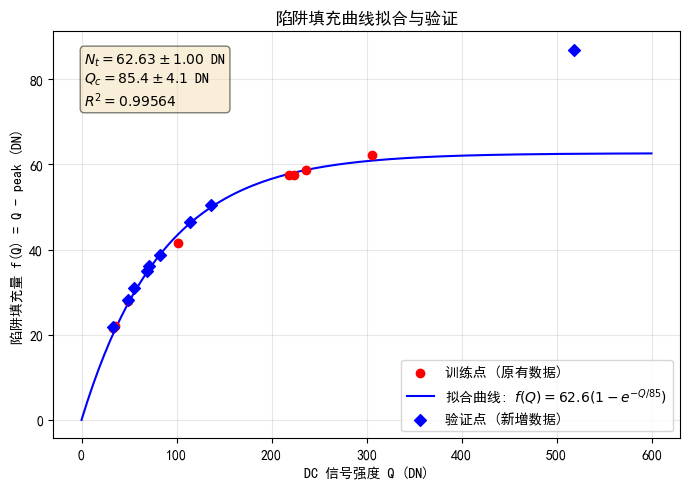

In [35]:
"""
陷阱型 Image Lag 模型拟合与验证（增加验证点散点）
=================================================
原有8点拟合 Mitscherlich 曲线，新增9点作为验证散点（不参与拟合）
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ------------------------------------------------------------------
# 1. 原有训练数据 (Q, peak)
# ------------------------------------------------------------------
train_data = [
    ( 33.32,   11.79 ),
    ( 35.28,   13.19 ),
    ( 48.71,   20.86 ),
    (101.98,   60.36 ),
    (218.43,  160.95 ),
    (223.47,  166.01 ),
    (236.24,  177.66 ),
    (305.86,  243.58 ),
]

Q_train = np.array([d[0] for d in train_data])
peak_train = np.array([d[1] for d in train_data])
y_train = Q_train - peak_train   # f(Q) 实测值

# ------------------------------------------------------------------
# 2. 新增验证数据 (Q, peak) - 仅用于散点图
# ------------------------------------------------------------------
val_data = [
    ( 33.15,   11.38 ),
    ( 48.88,   20.72 ),
    ( 55.43,   24.54 ),
    ( 68.96,   34.04 ),
    ( 71.09,   35.00 ),
    ( 82.08,   43.38 ),
    (113.95,   67.55 ),
    (136.37,   85.84 ),
    (518.23,  431.33 ),
]

Q_val = np.array([d[0] for d in val_data])
peak_val = np.array([d[1] for d in val_data])
y_val = Q_val - peak_val   # 验证点的 f(Q) 实测值

# ------------------------------------------------------------------
# 3. 模型定义与拟合 (仅基于训练集)
# ------------------------------------------------------------------
def f_mitscherlich(Q, Nt, Qc):
    return Nt * (1 - np.exp(-Q / Qc))

p0 = [40, 200]
popt, pcov = curve_fit(f_mitscherlich, Q_train, y_train, p0=p0, maxfev=10000)
Nt, Qc = popt
perr = np.sqrt(np.diag(pcov))

# 训练集上的统计
y_train_fit = f_mitscherlich(Q_train, Nt, Qc)
res_train = y_train - y_train_fit
rms_train = np.sqrt(np.mean(res_train**2))
ss_res = np.sum(res_train**2)
ss_tot = np.sum((y_train - np.mean(y_train))**2)
r2 = 1 - ss_res / ss_tot

# ------------------------------------------------------------------
# 4. 打印拟合参数及验证点预测偏差
# ------------------------------------------------------------------
print("=" * 55)
print("拟合结果 (基于8个训练点): f(Q) = Nt * (1 - exp(-Q/Qc))")
print("=" * 55)
print(f"  Nt  = {Nt:.2f} ± {perr[0]:.2f} DN")
print(f"  Qc  = {Qc:.1f} ± {perr[1]:.1f} DN")
print(f"  R²  = {r2:.5f}")
print(f"  RMS = {rms_train:.3f} DN\n")

print("验证点预测 (模型外推):")
print(f"{'Q':>8}  {'peak':>8}  {'实测 f(Q)':>10}  {'预测 f(Q)':>10}  {'残差':>8}  {'相对误差%':>10}")
for i in range(len(Q_val)):
    pred = f_mitscherlich(Q_val[i], Nt, Qc)
    resid = y_val[i] - pred
    rel_err = 100 * resid / y_val[i] if y_val[i] != 0 else np.nan
    print(f"{Q_val[i]:8.2f}  {peak_val[i]:8.2f}  {y_val[i]:10.3f}  {pred:10.3f}  {resid:8.3f}  {rel_err:9.2f}%")

# ------------------------------------------------------------------
# 5. 绘图: 只显示拟合曲线 + 训练点 + 验证点散点
# ------------------------------------------------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 5))
Q_plot = np.linspace(0, 600, 200)   # 横轴范围稍微扩大以包含验证点
f_plot = f_mitscherlich(Q_plot, Nt, Qc)

# 训练点 (红色圆点)
plt.scatter(Q_train, y_train, color='red', label='训练点 (原有数据)', zorder=5)
# 拟合曲线
plt.plot(Q_plot, f_plot, 'b-', label=f'拟合曲线: $f(Q) = {Nt:.1f}(1-e^{{-Q/{Qc:.0f}}})$')
# 验证点 (蓝色菱形)
plt.scatter(Q_val, y_val, color='blue', marker='D', label='验证点 (新增数据)', zorder=5)

plt.xlabel('DC 信号强度 Q (DN)')
plt.ylabel('陷阱填充量 f(Q) = Q - peak (DN)')
plt.title('陷阱填充曲线拟合与验证')
plt.legend()
plt.grid(alpha=0.3)

# 参数文本框
textstr = f'$N_t = {Nt:.2f} \\pm {perr[0]:.2f}$ DN\n$Q_c = {Qc:.1f} \\pm {perr[1]:.1f}$ DN\n$R^2 = {r2:.5f}$'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('image_lag_fit_with_validation.png', dpi=150)
plt.show()

## 2. 释放核 Q 依赖拟合

数据：Sheet2（25 条 h(t) 曲线）× Sheet3（对应 f\_trap 总捕获电子数）

核心发现：不同 F 下归一化曲线形状不同 → 核与 F 相关 → 双指数两陷阱模型

### 2.1 归一化原始曲线（按 f_trap 着色）

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

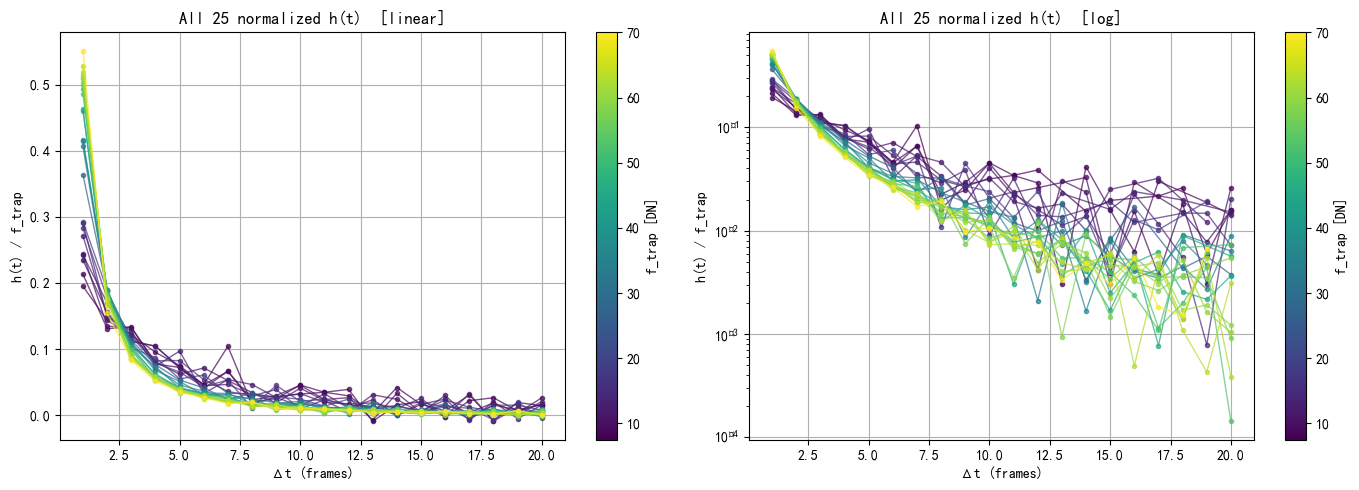

f_trap 范围: 7.5 ~ 70.0 DN  (< 50: 15 条,  ≥ 50: 10 条)


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw2     = pd.read_excel('imagelag_data.xlsx', sheet_name='Sheet2', header=None)
H_raw    = raw2.iloc[1:, 1:].values.astype(float)
area_all = pd.read_excel('imagelag_data.xlsx', sheet_name='Sheet3',
                         header=None).values.flatten()[:25].astype(float)
dt       = np.arange(1, H_raw.shape[1] + 1)
H_norm   = H_raw / area_all[:, np.newaxis]

norm_c = plt.Normalize(area_all.min(), area_all.max())
cmap   = plt.cm.viridis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scale in zip(axes, ['linear', 'log']):
    for i in range(len(H_norm)):
        c    = cmap(norm_c(area_all[i]))
        vals = H_norm[i]
        if scale == 'log':
            valid = vals > 0
            ax.semilogy(dt[valid], vals[valid], 'o-', color=c, ms=3, lw=1, alpha=0.7)
        else:
            ax.plot(dt, vals, 'o-', color=c, ms=3, lw=1, alpha=0.7)
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_c),
                 ax=ax, label='f_trap [DN]')
    ax.set_xlabel('Δt (frames)');  ax.set_ylabel('h(t) / f_trap')
    ax.set_title(f'All 25 normalized h(t)  [{scale}]'); ax.grid(True)

plt.tight_layout()
plt.savefig('raw_normalized_curves.png', dpi=150)
plt.show()
print(f"f_trap 范围: {area_all.min():.1f} ~ {area_all.max():.1f} DN  "
      f"(< 50: {(area_all<50).sum()} 条,  ≥ 50: {(area_all>=50).sum()} 条)")

### 2.2 双指数逐条拟合验证（f_trap > 50）

Sheet2: 25 条曲线 × 20 时间步
Sheet3 f_trap(Q) 范围: 7.5 ~ 70.0 DN

f_trap > 50 的曲线: 10/25 条
成功拟合: 10/10 条

α1 (慢): 0.5147 ± 0.0350  τ1 = 1.52 ± 0.15 帧
α2 (快): 0.1466 ± 0.0124  τ2 = 0.52 ± 0.02 帧
RMS    : 0.01000 ± 0.00127


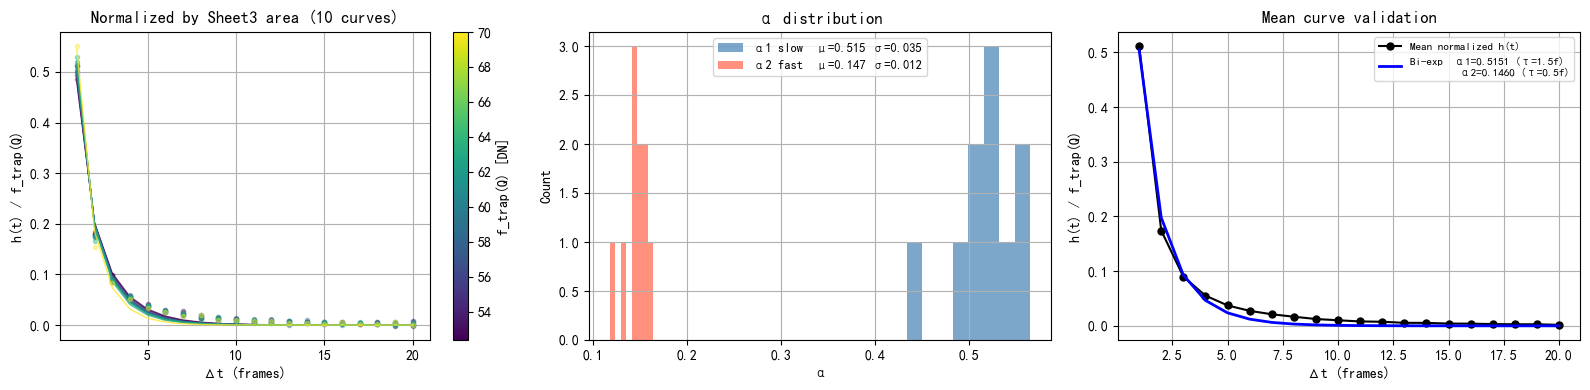


推荐参数 (f_trap>50, 10 条曲线):
  alpha1 = 0.5151  (慢陷阱, τ = 1.51 帧)
  alpha2 = 0.1460  (快陷阱, τ = 0.52 帧)


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── 读取数据 ───────────────────────────────────────────────────────────────
raw2 = pd.read_excel('imagelag_data.xlsx', sheet_name='Sheet2', header=None)
H_raw = raw2.iloc[1:, 1:].values.astype(float)   # shape (25, 20), h(t) 曲线

raw3 = pd.read_excel('imagelag_data.xlsx', sheet_name='Sheet3', header=None)
area_all = raw3.values.flatten()[:25].astype(float)  # 每条曲线对应的 f_trap(Q)（总捕获电荷）

dt = np.arange(1, H_raw.shape[1] + 1)   # Δt = 1..20
print(f"Sheet2: {H_raw.shape[0]} 条曲线 × {H_raw.shape[1]} 时间步")
print(f"Sheet3 f_trap(Q) 范围: {area_all.min():.1f} ~ {area_all.max():.1f} DN")

# ── 过滤：只保留 f_trap(Q) > 50 的曲线（信号足够大，噪声比低）────────────
mask = area_all > 50
H_filtered    = H_raw[mask]
area_filtered = area_all[mask]
print(f"\nf_trap > 50 的曲线: {mask.sum()}/{len(mask)} 条")

# ── 归一化：除以 Sheet3 的总捕获电荷，得到归一化释放核 h(t)/Σh ─────────────
H_norm = H_filtered / area_filtered[:, np.newaxis]

# ── 双指数模型 ─────────────────────────────────────────────────────────────
def biexp(t, A, alpha1, alpha2):
    return A * ((1 - alpha1) * alpha1**t + (1 - alpha2) * alpha2**t)

# ── 逐行拟合 ──────────────────────────────────────────────────────────────
results = []
for i, row in enumerate(H_norm):
    try:
        popt, _ = curve_fit(biexp, dt, row,
                            p0=[row[0]/2, 0.80, 0.35],
                            bounds=([0, 0.01, 0.01], [np.inf, 0.9999, 0.9999]),
                            maxfev=10000)
        A_f, a1, a2 = popt
        if a1 < a2:
            a1, a2 = a2, a1
        y_pred = biexp(dt, A_f, a1, a2)
        rms = np.sqrt(np.mean((row - y_pred)**2))
        results.append({'area': area_filtered[i], 'A': A_f, 'alpha1': a1, 'alpha2': a2,
                        'tau1': -1/np.log(a1), 'tau2': -1/np.log(a2),
                        'rms': rms, 'ok': True, 'idx': i})
    except Exception as e:
        results.append({'ok': False, 'idx': i})
        print(f"  curve {i}: 拟合失败 {e}")

ok = [r for r in results if r['ok']]
print(f"成功拟合: {len(ok)}/{len(H_norm)} 条\n")

alpha1_arr = np.array([r['alpha1'] for r in ok])
alpha2_arr = np.array([r['alpha2'] for r in ok])
tau1_arr   = np.array([r['tau1']   for r in ok])
tau2_arr   = np.array([r['tau2']   for r in ok])
rms_arr    = np.array([r['rms']    for r in ok])
area_ok    = np.array([r['area']   for r in ok])

print(f"α1 (慢): {alpha1_arr.mean():.4f} ± {alpha1_arr.std():.4f}  τ1 = {tau1_arr.mean():.2f} ± {tau1_arr.std():.2f} 帧")
print(f"α2 (快): {alpha2_arr.mean():.4f} ± {alpha2_arr.std():.4f}  τ2 = {tau2_arr.mean():.2f} ± {tau2_arr.std():.2f} 帧")
print(f"RMS    : {rms_arr.mean():.5f} ± {rms_arr.std():.5f}")

# ── 绘图 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
norm_c = plt.Normalize(area_ok.min(), area_ok.max())
for r in ok:
    c = plt.cm.viridis(norm_c(r['area']))
    i = r['idx']
    ax.plot(dt, H_norm[i], 'o', color=c, ms=3, alpha=0.4)
    ax.plot(dt, biexp(dt, r['A'], r['alpha1'], r['alpha2']), '-', color=c, lw=1, alpha=0.8)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_c)
plt.colorbar(sm, ax=ax, label='f_trap(Q) [DN]')
ax.set_xlabel('Δt (frames)'); ax.set_ylabel('h(t) / f_trap(Q)')
ax.set_title(f'Normalized by Sheet3 area ({len(ok)} curves)'); ax.grid(True)

ax = axes[1]
ax.hist(alpha1_arr, bins=8, alpha=0.7, color='steelblue',
        label=f'α1 slow  μ={alpha1_arr.mean():.3f} σ={alpha1_arr.std():.3f}')
ax.hist(alpha2_arr, bins=8, alpha=0.7, color='tomato',
        label=f'α2 fast  μ={alpha2_arr.mean():.3f} σ={alpha2_arr.std():.3f}')
ax.set_xlabel('α'); ax.set_ylabel('Count')
ax.set_title('α distribution'); ax.legend(fontsize=9); ax.grid(True)

ax = axes[2]
ok_indices = [r['idx'] for r in ok]
H_mean_norm = H_norm[ok_indices].mean(axis=0)
popt_m, _ = curve_fit(biexp, dt, H_mean_norm,
                      p0=[H_mean_norm[0]/2, alpha1_arr.mean(), alpha2_arr.mean()],
                      bounds=([0, 0.01, 0.01], [np.inf, 0.9999, 0.9999]))
A_m, a1_m, a2_m = popt_m
if a1_m < a2_m: a1_m, a2_m = a2_m, a1_m
ax.plot(dt, H_mean_norm, 'ko-', ms=5, label='Mean normalized h(t)')
ax.plot(dt, biexp(dt, A_m, a1_m, a2_m), 'b-', lw=2,
        label=f'Bi-exp  α1={a1_m:.4f} (τ={-1/np.log(a1_m):.1f}f)\n'
              f'         α2={a2_m:.4f} (τ={-1/np.log(a2_m):.1f}f)')
ax.set_xlabel('Δt (frames)'); ax.set_ylabel('h(t) / f_trap(Q)')
ax.set_title('Mean curve validation'); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('biexponential_fit_normalized.png', dpi=150)
plt.show()

print(f"\n推荐参数 (f_trap>50, {len(ok)} 条曲线):")
print(f"  alpha1 = {a1_m:.4f}  (慢陷阱, τ = {-1/np.log(a1_m):.2f} 帧)")
print(f"  alpha2 = {a2_m:.4f}  (快陷阱, τ = {-1/np.log(a2_m):.2f} 帧)")


### 2.3 联合全局优化（训练 / 测试分割）

同时优化 (α1, α2, A1max, Fc1) 4 个参数，软 SNR 加权，F > 15 随机对半分割。

  拟合参数
  慢陷阱  α1    = 0.7779   τ1 = 3.98 帧
  快陷阱  α2    = 0.2344   τ2 = 0.69 帧
  权重    A1max = 1.0000
          Fc1   = 78.5 DN  (A1=A1max/2 处)
  RMS     Train = 0.2453 DN
          Test  = 0.2697 DN

  核函数 h(t; F) = F · [A1(F)·g_fast(t) + (1−A1(F))·g_slow(t)]
  A1(F) = 1.0000 · (1 − exp(−F / 78.5))


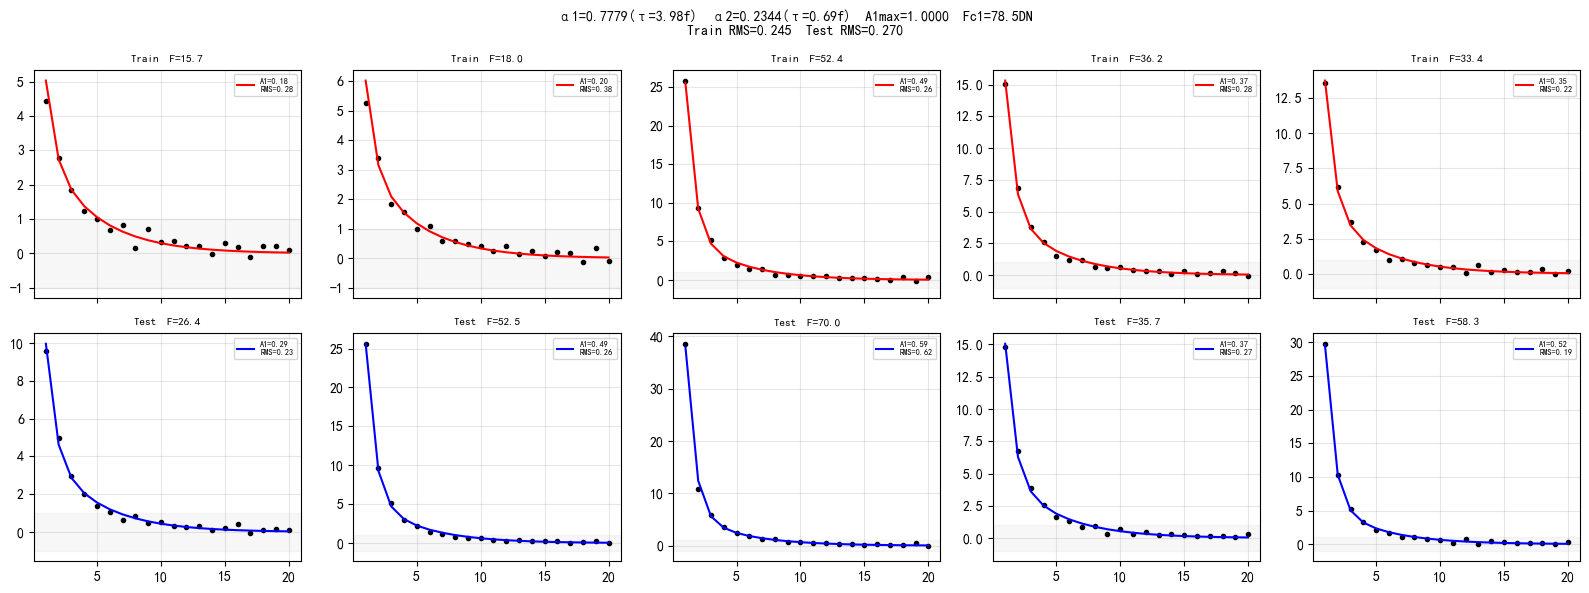

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, nnls

np.random.seed(42)

# ── 数据 ──────────────────────────────────────────────────────────────────
raw2  = pd.read_excel('imagelag_data.xlsx', sheet_name='Sheet2', header=None)
H_raw = raw2.iloc[1:, 1:].values.astype(float)          # (25, 20)
F_all = pd.read_excel('imagelag_data.xlsx', sheet_name='Sheet3',
                      header=None).values.flatten()[:25].astype(float)
dt    = np.arange(1, H_raw.shape[1] + 1)
NF    = 1.0   # 噪声本底 [DN]

# ── 训练/测试分割（F>15 随机对半）─────────────────────────────────────────
idx   = np.where(F_all > 15)[0]
np.random.shuffle(idx)
train_idx = idx[:len(idx)//2]
test_idx  = idx[len(idx)//2:]

# ── 联合优化 ──────────────────────────────────────────────────────────────
def residuals(params):
    a1, a2, A1max, Fc1 = params
    if a1 <= a2:
        return np.full(len(train_idx) * len(dt), 1e4)
    g_sl = (1-a1)*a1**dt;  g_sl /= g_sl.sum()
    g_fa = (1-a2)*a2**dt;  g_fa /= g_fa.sum()
    r = []
    for i in train_idx:
        A1   = A1max * (1 - np.exp(-F_all[i] / Fc1))
        pred = F_all[i] * (A1*g_fa + (1-A1)*g_sl)
        w    = np.clip(np.abs(H_raw[i]) / NF - 0.5, 0.0, 1.0)
        r.append(w * (H_raw[i] - pred))
    return np.concatenate(r)

res = least_squares(residuals, [0.72, 0.23, 0.80, 50.0],
                    bounds=([0.05, 0.01, 0.01, 5.0],
                            [0.9999, 0.60, 1.0, 500.0]),
                    method='trf', max_nfev=10000)
a1, a2, A1max, Fc1 = res.x

# ── 基函数与预测 ───────────────────────────────────────────────────────────
g_slow = (1-a1)*a1**dt;  g_slow /= g_slow.sum()
g_fast = (1-a2)*a2**dt;  g_fast /= g_fast.sum()

def A1_model(F):
    return A1max * (1 - np.exp(-F / Fc1))

def predict(i):
    A1 = A1_model(F_all[i])
    return F_all[i] * (A1*g_fast + (1-A1)*g_slow)

def rms_sig(i):
    mask = np.abs(H_raw[i]) > NF
    return np.sqrt(np.mean((H_raw[i,mask] - predict(i)[mask])**2)) if mask.any() else 0.

rms_tr = np.mean([rms_sig(i) for i in train_idx])
rms_te = np.mean([rms_sig(i) for i in test_idx])

# ── 参数输出 ──────────────────────────────────────────────────────────────
print("=" * 48)
print("  拟合参数")
print("=" * 48)
print(f"  慢陷阱  α1    = {a1:.4f}   τ1 = {-1/np.log(a1):.2f} 帧")
print(f"  快陷阱  α2    = {a2:.4f}   τ2 = {-1/np.log(a2):.2f} 帧")
print(f"  权重    A1max = {A1max:.4f}")
print(f"          Fc1   = {Fc1:.1f} DN  (A1=A1max/2 处)")
print(f"  RMS     Train = {rms_tr:.4f} DN")
print(f"          Test  = {rms_te:.4f} DN")
print("=" * 48)
print(f"\n  核函数 h(t; F) = F · [A1(F)·g_fast(t) + (1−A1(F))·g_slow(t)]")
print(f"  A1(F) = {A1max:.4f} · (1 − exp(−F / {Fc1:.1f}))")

# ── 绘图 ──────────────────────────────────────────────────────────────────
ncols = 5
fig, axes = plt.subplots(2, ncols, figsize=(16, 6), sharex=True)

for row, (label, idx_set, color) in enumerate(
        [('Train', train_idx, 'r'), ('Test', test_idx, 'b')]):
    for col in range(ncols):
        ax = axes[row, col]
        if col >= len(idx_set):
            ax.set_visible(False); continue
        i = idx_set[col]
        ax.axhspan(-NF, NF, alpha=0.06, color='gray')
        ax.plot(dt, H_raw[i], 'ko', ms=3)
        ax.plot(dt, predict(i), f'{color}-', lw=1.5,
                label=f'A1={A1_model(F_all[i]):.2f}\nRMS={rms_sig(i):.2f}')
        ax.set_title(f'{label}  F={F_all[i]:.1f}', fontsize=8)
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

fig.suptitle(
    f'α1={a1:.4f}(τ={-1/np.log(a1):.2f}f)  α2={a2:.4f}(τ={-1/np.log(a2):.2f}f)  '
    f'A1max={A1max:.4f}  Fc1={Fc1:.1f}DN\n'
    f'Train RMS={rms_tr:.3f}  Test RMS={rms_te:.3f}', fontsize=10)
plt.tight_layout()
plt.savefig('train_test_validation.png', dpi=120)
plt.show()


  i       F   A1_pred   RMS_sig
  0    7.45    0.0905    0.4441
  1    8.16    0.0987    0.5077
  2    8.97    0.1079    0.3253
  3   10.01    0.1197    0.3485
  4   11.84    0.1399    0.2734
  5   12.02    0.1419    0.3643
  6   14.01    0.1634    0.2357

  Low-F RMS = 0.3570  (Train=0.2453  Test=0.2697)


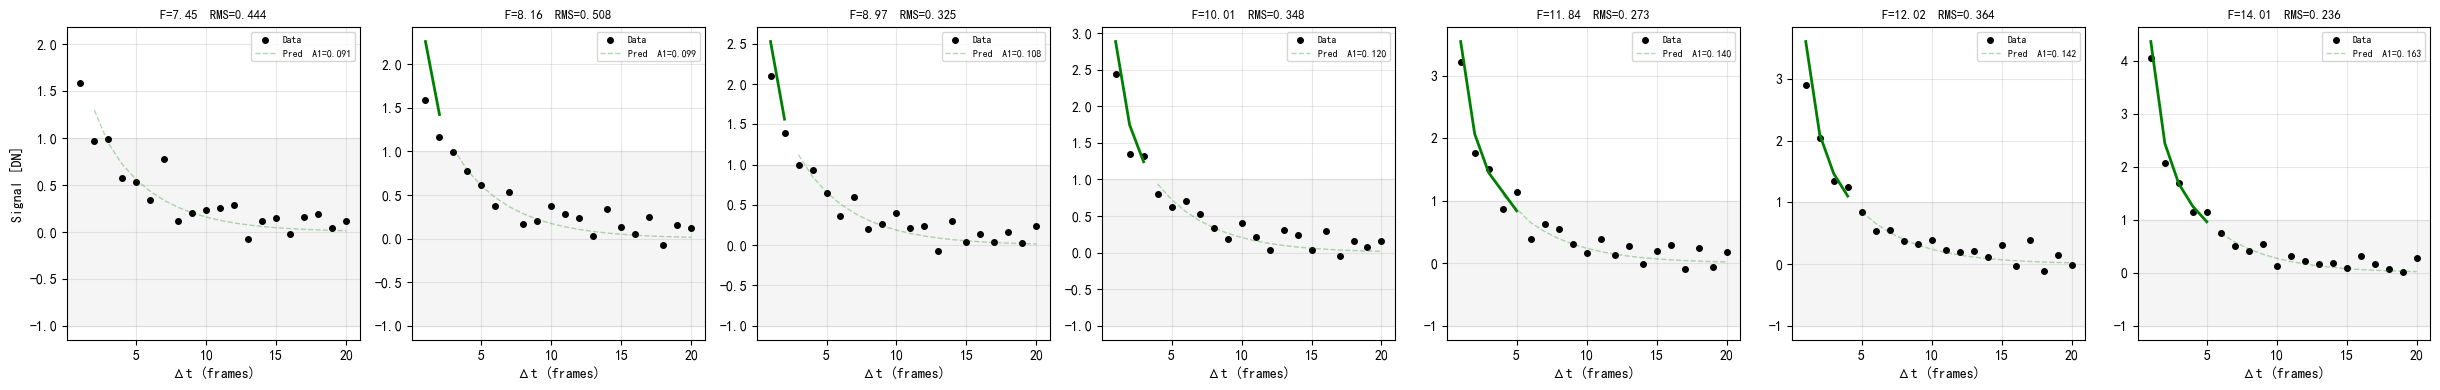

In [42]:
"""F ≤ 15 外推验证（完全未参与训练）"""

low_idx = np.where(F_all <= 15)[0]

print(f"{'i':>3}  {'F':>6}  {'A1_pred':>8}  {'RMS_sig':>8}")
for i in low_idx:
    print(f"{i:3d}  {F_all[i]:6.2f}  {A1_model(F_all[i]):8.4f}  {rms_sig(i):8.4f}")

rms_lw = np.mean([rms_sig(i) for i in low_idx])
print(f"\n  Low-F RMS = {rms_lw:.4f}  (Train={rms_tr:.4f}  Test={rms_te:.4f})")

ncols = min(len(low_idx), 10)
fig, axes = plt.subplots(1, ncols, figsize=(3.5*ncols, 4))
if ncols == 1: axes = [axes]

for col, i in enumerate(low_idx[:ncols]):
    ax   = axes[col]
    mask = np.abs(H_raw[i]) > NF
    ax.axhspan(-NF, NF, alpha=0.08, color='gray')
    ax.plot(dt, H_raw[i], 'ko', ms=4, label='Data')
    ax.plot(dt[mask],  predict(i)[mask],  'g-',  lw=2.0)
    ax.plot(dt[~mask], predict(i)[~mask], 'g--', lw=1.0, alpha=0.3,
            label=f'Pred  A1={A1_model(F_all[i]):.3f}')
    ax.set_title(f'F={F_all[i]:.2f}  RMS={rms_sig(i):.3f}', fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Δt (frames)')
    if col == 0: ax.set_ylabel('Signal [DN]')

plt.tight_layout()
plt.savefig('low_f_validation.png', dpi=120)
plt.show()


## 3. 集成模型参数

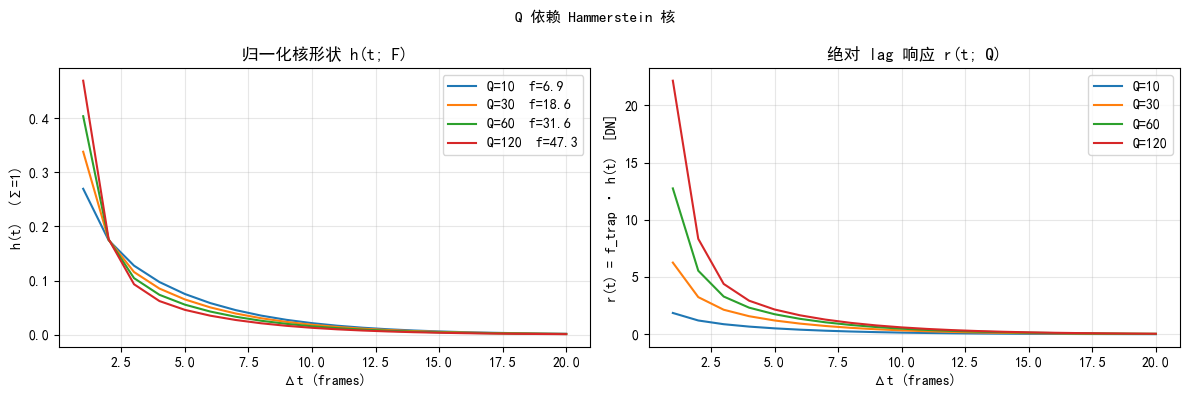

  最终参数汇总
  填充模型  Nt  = 62.63  DN
            Qc  = 85.4  DN
  慢陷阱    α1  = 0.7779   τ1 = 3.98 帧
  快陷阱    α2  = 0.2344   τ2 = 0.69 帧
  权重      A1max = 1.0
            Fc1   = 78.5 DN


In [40]:
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════
# 拟合参数汇总
# ══════════════════════════════════════════════════════════════════

# Section 1 — 陷阱填充 (Mitscherlich)
NT  = 62.63   # 陷阱容量    [DN]
QC  = 85.4    # 半饱和信号  [DN]

# Section 2 — Q 依赖释放核 (联合全局优化)
ALPHA1 = 0.7779   # 慢陷阱  τ1 ≈ 3.98 帧
ALPHA2 = 0.2344   # 快陷阱  τ2 ≈ 0.69 帧
A1MAX  = 1.0      # 最大快陷阱占比
FC1    = 78.5     # 特征填充电荷 [DN]
LAG_T  = 20       # 拖尾窗口（帧）


def f_trap(Q):
    """静态非线性：被陷阱捕获的总电荷 [DN]"""
    return NT * (1.0 - np.exp(-np.clip(Q, 0, None) / QC))


def make_lag_kernel(f, T=LAG_T):
    """
    Q 依赖双指数释放核 h(t; f_trap)
    返回 shape (1, T+1)，t=0 占位为 0，其余 Σ = 1
    """
    t  = np.arange(1, T + 1)
    A1 = A1MAX * (1.0 - np.exp(-max(float(f), 1e-6) / FC1))
    g_slow = (1-ALPHA1)*ALPHA1**t;  g_slow /= g_slow.sum()
    g_fast = (1-ALPHA2)*ALPHA2**t;  g_fast /= g_fast.sum()
    return np.concatenate([[0.0], A1*g_fast + (1-A1)*g_slow]).reshape(1, -1)


def apply_image_lag(frame, return_lag=False):
    """
    Q 依赖 Hammerstein image-lag 前向模型
      trapped  = f_trap(Q)              逐像素
      remain   = Q − trapped            当帧读出
      kernel   = h(t; mean(trapped))    用行均值 f 近似空间均匀核
      lag      = trapped ⊛ kernel       沿 x 方向拖尾
      out      = remain + lag
    """
    H, W    = frame.shape
    trapped = f_trap(frame)
    remain  = frame - trapped
    kernel  = make_lag_kernel(trapped.mean())
    lag     = fftconvolve(trapped, kernel, mode='full')[:H, :W]
    out     = remain + lag
    return (out, lag) if return_lag else out


# ── 核形状可视化 ──────────────────────────────────────────────────
Q_vals  = [10, 30, 60, 120]
t_plot  = np.arange(1, LAG_T + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for Q in Q_vals:
    f = f_trap(Q)
    h = make_lag_kernel(f).flatten()[1:]
    ax.plot(t_plot, h, label=f'Q={Q}  f={f:.1f}')
ax.set_xlabel('Δt (frames)'); ax.set_ylabel('h(t)  (Σ=1)')
ax.set_title('归一化核形状 h(t; F)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for Q in Q_vals:
    f = f_trap(Q)
    h = make_lag_kernel(f).flatten()[1:]
    ax.plot(t_plot, f * h, label=f'Q={Q}')
ax.set_xlabel('Δt (frames)'); ax.set_ylabel('r(t) = f_trap · h(t)  [DN]')
ax.set_title('绝对 lag 响应 r(t; Q)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Q 依赖 Hammerstein 核', fontsize=11)
plt.tight_layout()
plt.savefig('lag_kernel_final.png', dpi=120)
plt.show()

print("=" * 44)
print("  最终参数汇总")
print("=" * 44)
print(f"  填充模型  Nt  = {NT}  DN")
print(f"            Qc  = {QC}  DN")
print(f"  慢陷阱    α1  = {ALPHA1}   τ1 = {-1/np.log(ALPHA1):.2f} 帧")
print(f"  快陷阱    α2  = {ALPHA2}   τ2 = {-1/np.log(ALPHA2):.2f} 帧")
print(f"  权重      A1max = {A1MAX}")
print(f"            Fc1   = {FC1} DN")
print("=" * 44)

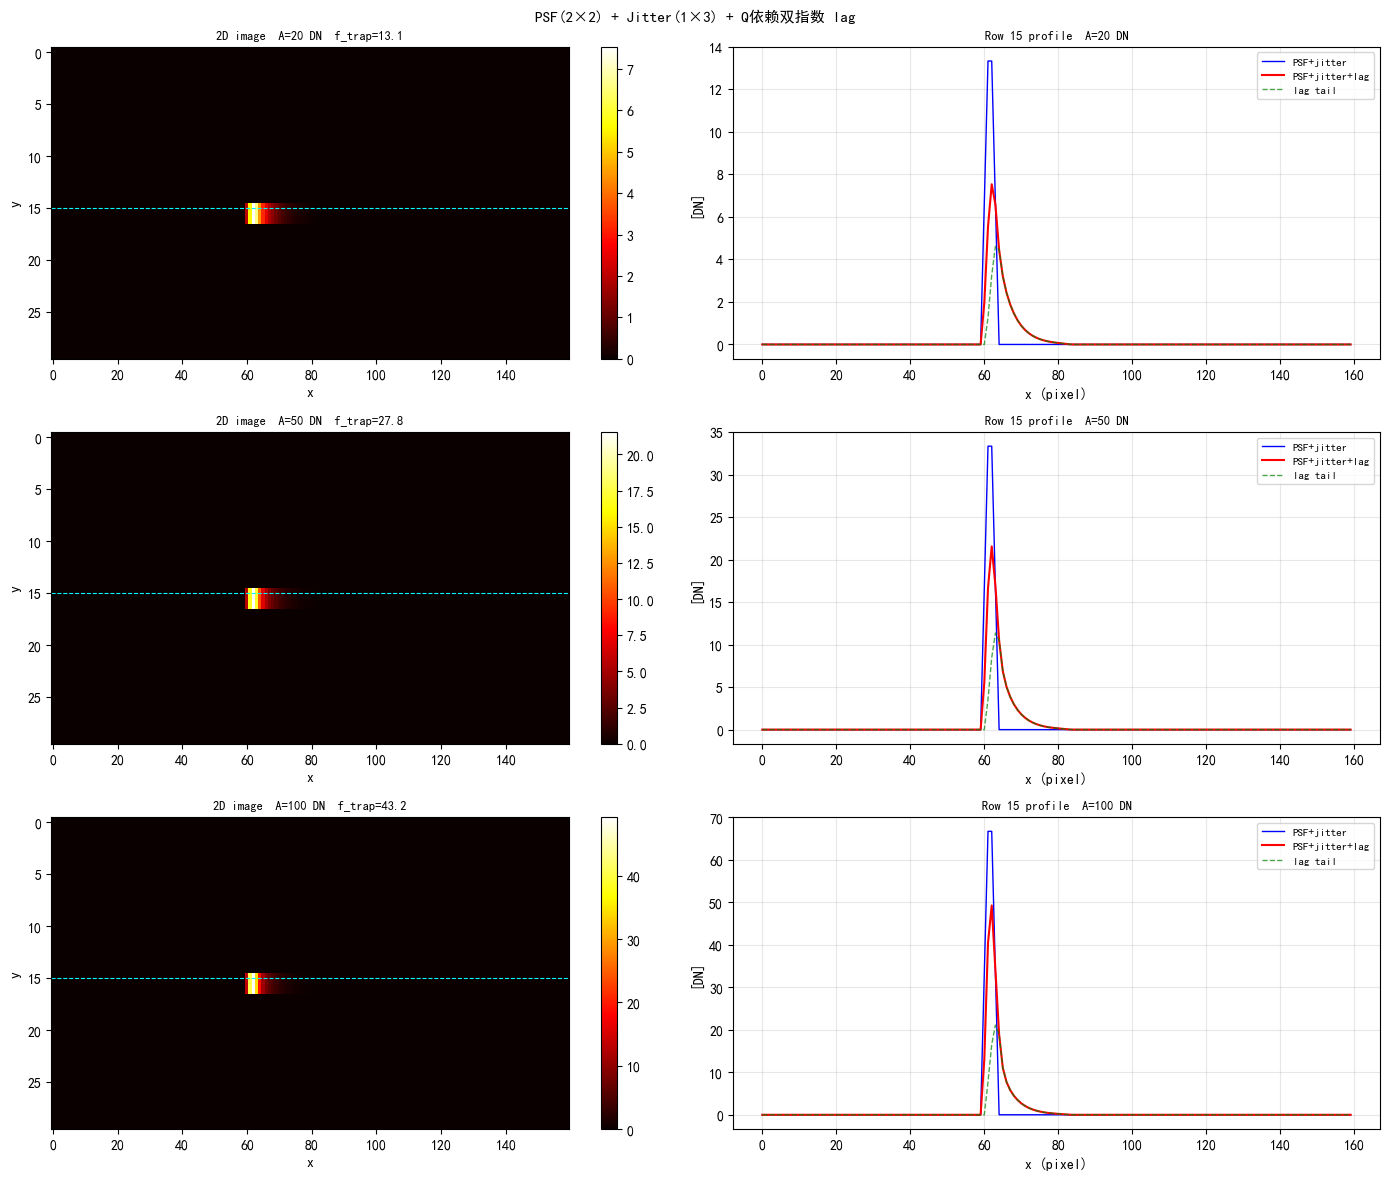

In [41]:
"""PSF + Jitter + 新 Q 依赖 lag 模型前向仿真"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# ── 参数（填充模型 Section1 + 联合优化 Section2）─────────────────
NT, QC         = 62.63, 85.4
ALPHA1, ALPHA2 = 0.7779, 0.2344
A1MAX, FC1     = 1.0, 78.5
T_LAG          = 20

def ftrap(Q):
    return NT * (1 - np.exp(-np.clip(Q, 0, None) / QC))

def lag_kernel(f):
    t    = np.arange(1, T_LAG + 1)
    A1   = A1MAX * (1 - np.exp(-max(float(f), 1e-6) / FC1))
    g_sl = (1-ALPHA1)*ALPHA1**t;  g_sl /= g_sl.sum()
    g_fa = (1-ALPHA2)*ALPHA2**t;  g_fa /= g_fa.sum()
    return np.concatenate([[0.], A1*g_fa + (1-A1)*g_sl]).reshape(1, -1)

# ── 场景 ─────────────────────────────────────────────────────────
H, W   = 30, 160
Y0, X0 = 15, 60          # 缺陷位置
A_vals = [20, 50, 100]   # 缺陷幅度

PSF    = np.ones((2, 2))            # 2×2 box PSF
JITTER = np.ones((1, 3)) / 3.0     # 1×3 jitter

fig, axes = plt.subplots(len(A_vals), 2, figsize=(14, 4*len(A_vals)))

for row, A in enumerate(A_vals):
    scene    = np.zeros((H, W)); scene[Y0, X0] = A

    # PSF → jitter
    jittered = fftconvolve(fftconvolve(scene, PSF, 'full')[:H,:W],
                           JITTER, 'full')[:H, :W]

    # 新 lag
    trapped  = ftrap(jittered)
    f_mean   = trapped[trapped > 0.1].mean() if (trapped > 0.1).any() else 1.0
    lag      = fftconvolve(trapped, lag_kernel(f_mean), 'full')[:H, :W]
    obs      = (jittered - trapped) + lag

    ax = axes[row, 0]
    im = ax.imshow(obs, aspect='auto', cmap='hot', origin='upper')
    ax.axhline(Y0, color='cyan', lw=0.8, ls='--')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'2D image  A={A} DN  f_trap={ftrap(A):.1f}', fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    ax = axes[row, 1]
    ax.plot(jittered[Y0], 'b-',  lw=1,   label='PSF+jitter')
    ax.plot(obs[Y0],      'r-',  lw=1.5, label='PSF+jitter+lag')
    ax.plot(lag[Y0],      'g--', lw=1,   alpha=0.7, label='lag tail')
    ax.set_title(f'Row {Y0} profile  A={A} DN', fontsize=9)
    ax.set_xlabel('x (pixel)'); ax.set_ylabel('[DN]')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('PSF(2×2) + Jitter(1×3) + Q依赖双指数 lag', fontsize=11)
plt.tight_layout()
plt.savefig('psf_lag_combined.png', dpi=120)
plt.show()